# Clinical Trial Analytics: Dual-Endpoint Efficacy, Safety, and Benefit-Risk Dose Policy

**The problem.** A clinical programme does not live or die on efficacy alone. A drug that pushes response rates but pushes grade-≥3 adverse events harder is a failed label. Dose selection, subgroup defensibility, and final regulatory narrative all rest on a *joint* view of efficacy and safety — and the evidence bar is calibrated probabilities at the patient level, not just headline rates. The question this notebook answers: **given a Phase II/III-style cohort with both an efficacy outcome and a severe-AE outcome, which dose maximises patient benefit net of harm, how sensitive is that choice to our safety preferences, and does it hold up across subgroups?**

**The approach.** On a simulated 5,200-patient dose-escalation trial:

1. Dose-level efficacy and safety profiles — the coarse signal before any modelling.
2. Dual-endpoint model benchmark (logistic regression vs. random forest) with ROC-AUC, PR-AUC, and Brier score.
3. Calibration assessment — because decisions use *probabilities*, not just rankings.
4. Patient-level **benefit-risk utility** combining both predicted probabilities, with a tunable safety penalty.
5. Subgroup consistency (sex, region, elderly) and decision-sensitivity sweep to expose where the dose recommendation would change.

**Audience.** Biostatisticians, clinical pharmacologists, and cross-functional teams preparing a Phase III design or regulatory defence of a dose selection.

## 0. Setup and reproducibility

All randomness is seeded so cohort simulation, model fits, calibration curves, subgroup tables, and the final dose recommendation are identical across runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(123)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating a dual-endpoint clinical cohort

A realistic trial has two latent signals that interact but don't align: efficacy (response driven by dose, biomarker, age, comorbidity) and safety (severe AEs driven by dose, age, comorbidity, eGFR). We simulate both from explicit logistic data-generating mechanisms so the downstream analysis has a ground truth to validate against, while still exposing the same benchmarking, calibration, and benefit-risk machinery that a real trial pipeline would apply.

In [2]:
n = 5200

trial = pd.DataFrame(
    {
        "age": np.random.randint(18, 86, size=n),
        "sex": np.random.choice(["F", "M"], size=n),
        "baseline_biomarker": np.random.normal(0.95, 0.38, size=n),
        "comorbidity_index": np.random.poisson(1.3, size=n),
        "baseline_severity": np.clip(np.random.normal(5.2, 1.6, size=n), 0.2, 10.0),
        "egfr": np.clip(np.random.normal(82, 18, size=n), 20, 140),
        "dose_mg": np.random.choice([25, 50, 100, 150], p=[0.20, 0.35, 0.30, 0.15], size=n),
        "site_region": np.random.choice(["NA", "EU", "APAC", "LATAM"], p=[0.40, 0.33, 0.18, 0.09], size=n),
    }
)

trial["elderly"] = (trial["age"] >= 65).astype(int)

# Latent efficacy signal
resp_logit = (
    -1.00
    + 0.011 * trial["dose_mg"].to_numpy()
    + 0.85 * trial["baseline_biomarker"].to_numpy()
    - 0.016 * trial["age"].to_numpy()
    - 0.19 * trial["comorbidity_index"].to_numpy()
    - 0.08 * trial["baseline_severity"].to_numpy()
    + 0.003 * trial["egfr"].to_numpy()
    + np.where(trial["site_region"].to_numpy() == "EU", 0.06, 0.0)
)

# Latent severe AE signal
ae_logit = (
    -2.15
    + 0.010 * trial["dose_mg"].to_numpy()
    + 0.018 * trial["age"].to_numpy()
    + 0.33 * trial["comorbidity_index"].to_numpy()
    + 0.09 * trial["baseline_severity"].to_numpy()
    - 0.004 * trial["egfr"].to_numpy()
    + np.where(trial["sex"].to_numpy() == "F", 0.05, 0.0)
)

trial["efficacy_response"] = np.random.binomial(1, 1 / (1 + np.exp(-resp_logit)), size=n)
trial["grade3_ae"] = np.random.binomial(1, 1 / (1 + np.exp(-ae_logit)), size=n)

trial.head()

,age,sex,baseline_biomarker,comorbidity_index,baseline_severity,egfr,dose_mg,site_region,elderly,efficacy_response,grade3_ae
0,84,F,0.473789,2,4.832247,110.817091,25,NA,1,0,0
1,35,M,1.069052,0,5.376465,85.041104,50,EU,0,0,0
2,75,M,0.956826,0,5.709070,105.253319,50,NA,1,1,1
3,65,F,1.152852,0,4.910692,65.296574,150,APAC,1,1,1
4,50,M,0.927373,2,6.066153,72.462848,100,NA,0,0,1


In [3]:
print(f"Patients: {len(trial):,}")
print(f"Efficacy response rate: {trial['efficacy_response'].mean():.2%}")
print(f"Grade >=3 AE rate: {trial['grade3_ae'].mean():.2%}")

Patients: 5,200
Efficacy response rate: 36.83%
Grade >=3 AE rate: 52.12%


## 2. Dose-level efficacy and safety profiles

Before any model, we look at the raw dose → response and dose → AE rates. This is the "does the data agree with pharmacology?" check: if response doesn't increase with dose or AE doesn't increase faster at the top dose, we stop and audit before modelling noise.

In [4]:
profile = trial.groupby("dose_mg", as_index=False).agg(
    response_rate=("efficacy_response", "mean"),
    severe_ae_rate=("grade3_ae", "mean"),
    n_patients=("dose_mg", "size"),
)
profile

,dose_mg,response_rate,severe_ae_rate,n_patients
0,25,0.243133,0.387589,983
1,50,0.308758,0.458426,1804
2,100,0.421154,0.589103,1560
3,150,0.541618,0.683470,853


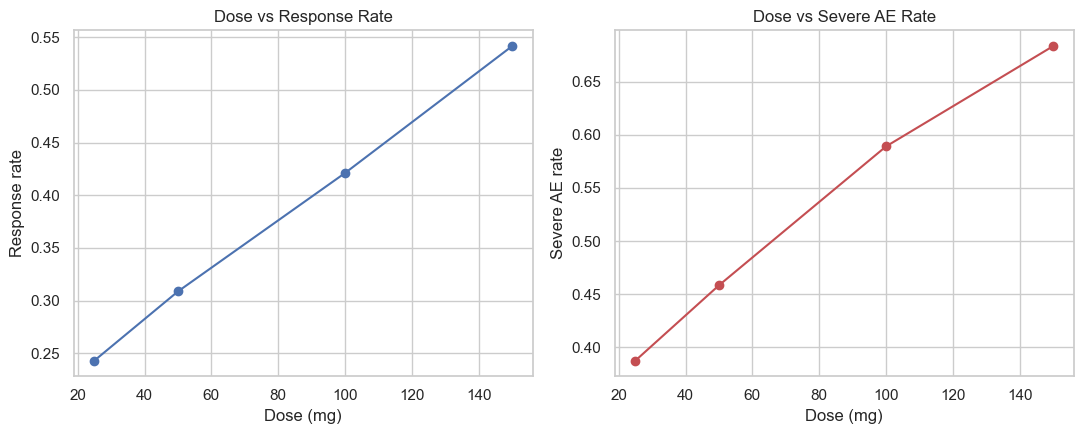

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(profile["dose_mg"], profile["response_rate"], marker="o", color="#4C72B0")
ax[0].set_title("Dose vs Response Rate")
ax[0].set_xlabel("Dose (mg)")
ax[0].set_ylabel("Response rate")

ax[1].plot(profile["dose_mg"], profile["severe_ae_rate"], marker="o", color="#C44E52")
ax[1].set_title("Dose vs Severe AE Rate")
ax[1].set_xlabel("Dose (mg)")
ax[1].set_ylabel("Severe AE rate")

plt.tight_layout()
plt.show()

**What to read here.** The two curves are the *clinical tension* the rest of the notebook resolves. Response rises with dose — the efficacy story. Severe AE rises with dose too — the safety story. If both monotone, the therapeutic-window question is quantitative (which dose is best, and by how much?) rather than qualitative. If AE rises faster than response at the top dose, that dose is almost certainly off the table regardless of modelling sophistication.

## 3. Features and stratified splits

Both endpoints are modelled on the same covariate set. We stratify the train/test split on each outcome separately (efficacy and safety have different prevalence) to protect against imbalanced holdout — essential when AE rates are modest and an unstratified split can leave too few positives in test to evaluate calibration.

In [6]:
features = [
    "age",
    "sex",
    "baseline_biomarker",
    "comorbidity_index",
    "baseline_severity",
    "egfr",
    "dose_mg",
    "site_region",
    "elderly",
]

num_cols = [
    "age",
    "baseline_biomarker",
    "comorbidity_index",
    "baseline_severity",
    "egfr",
    "dose_mg",
    "elderly",
]
cat_cols = ["sex", "site_region"]

prep = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

X = trial[features]
y_eff = trial["efficacy_response"]
y_ae = trial["grade3_ae"]

X_train_eff, X_test_eff, y_train_eff, y_test_eff = train_test_split(
    X, y_eff, test_size=0.30, random_state=123, stratify=y_eff
)

X_train_ae, X_test_ae, y_train_ae, y_test_ae = train_test_split(
    X, y_ae, test_size=0.30, random_state=123, stratify=y_ae
)

## 4. Benchmark: logistic regression vs. random forest

Two deliberately different learners on each endpoint:

- **Logistic regression** — the reference in clinical statistics. Interpretable coefficients, defensible to regulators, tends to under-fit genuine non-linearities.
- **Random forest** — captures interactions and non-linear effects; interpretability via permutation or SHAP if needed.

Three metrics, because one is never enough for a clinical model:

- **ROC-AUC** — ranking quality.
- **PR-AUC** — the metric that matters when the positive class is rare (severe AE in particular).
- **Brier score** — probability quality. A low Brier is necessary for calibrated decisions downstream.

In [7]:
def build_models():
    logit = Pipeline(
        [
            ("prep", prep),
            ("clf", LogisticRegression(max_iter=500, random_state=123)),
        ]
    )
    rf = Pipeline(
        [
            ("prep", prep),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=320,
                    max_depth=9,
                    min_samples_leaf=12,
                    random_state=123,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    return {"Logistic": logit, "RandomForest": rf}


def evaluate_models(X_train, X_test, y_train, y_test, endpoint_name: str):
    rows = []
    preds = {}
    for name, model in build_models().items():
        model.fit(X_train, y_train)
        p = model.predict_proba(X_test)[:, 1]
        preds[name] = (model, p)
        rows.append(
            {
                "endpoint": endpoint_name,
                "model": name,
                "roc_auc": roc_auc_score(y_test, p),
                "pr_auc": average_precision_score(y_test, p),
                "brier": brier_score_loss(y_test, p),
            }
        )
    return pd.DataFrame(rows).sort_values("roc_auc", ascending=False), preds

res_eff, preds_eff = evaluate_models(X_train_eff, X_test_eff, y_train_eff, y_test_eff, "efficacy_response")
res_ae, preds_ae = evaluate_models(X_train_ae, X_test_ae, y_train_ae, y_test_ae, "grade3_ae")

benchmark = pd.concat([res_eff, res_ae], ignore_index=True)
benchmark

,endpoint,model,roc_auc,pr_auc,brier
0,efficacy_response,Logistic,0.683331,0.545525,0.210871
1,efficacy_response,RandomForest,0.649972,0.512548,0.217756
2,grade3_ae,Logistic,0.674230,0.667264,0.227480
3,grade3_ae,RandomForest,0.652427,0.651255,0.232398


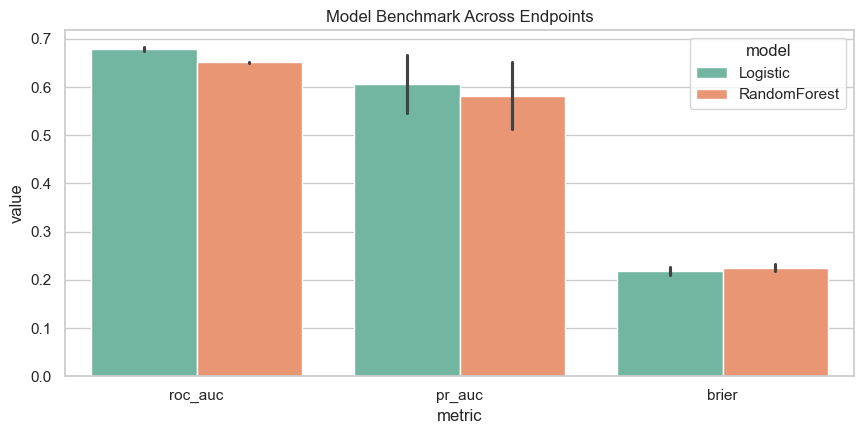

In [8]:
plt.figure(figsize=(8.8, 4.5))
plot_df = benchmark.melt(id_vars=["endpoint", "model"], value_vars=["roc_auc", "pr_auc", "brier"], var_name="metric")
sns.barplot(data=plot_df, x="metric", y="value", hue="model", palette="Set2")
plt.title("Model Benchmark Across Endpoints")
plt.tight_layout()
plt.show()

**What to read here.** Compare ROC-AUC and PR-AUC across both models and both endpoints. A small ROC-AUC gap with a larger PR-AUC gap signals the more flexible model is doing real work on the rare-positive class (typically the AE endpoint). Brier is lower-is-better — the candidate with comparable discrimination and the lower Brier is the model we should trust to produce *probabilities* fit for benefit-risk scoring, not just rankings.

## 5. Champion selection and calibration

We take the best-AUC model per endpoint forward, then check **calibration** — whether the predicted probability matches the observed rate at each bin of risk. A model can discriminate well (high AUC) while producing miscalibrated probabilities, and in clinical decision contexts miscalibration is what actually misleads a clinician. The diagonal is perfect calibration; the curve tells us whether we are over- or under-confident at each risk level.

Efficacy champion: Logistic
Safety champion  : Logistic


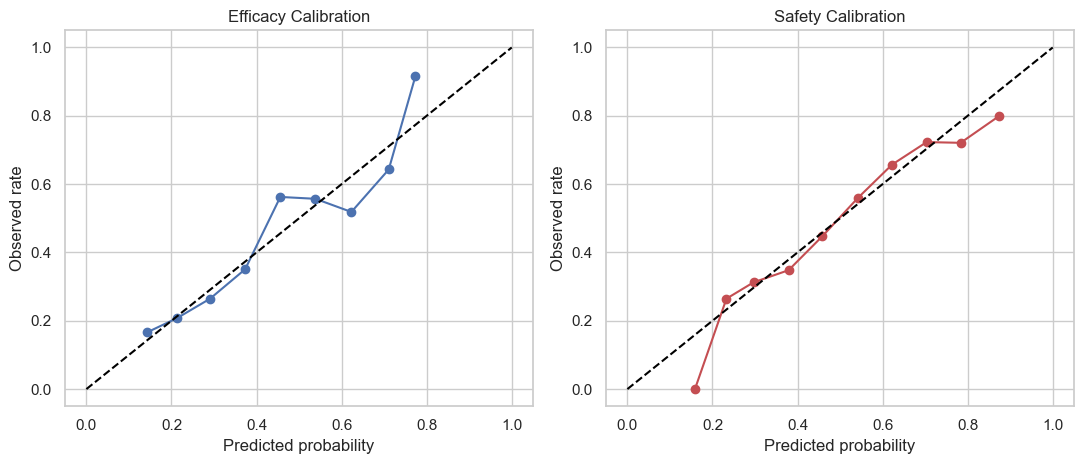

In [9]:
champ_eff_name = res_eff.iloc[0]["model"]
champ_ae_name = res_ae.iloc[0]["model"]

model_eff, p_eff = preds_eff[champ_eff_name]
model_ae, p_ae = preds_ae[champ_ae_name]

print(f"Efficacy champion: {champ_eff_name}")
print(f"Safety champion  : {champ_ae_name}")

frac_eff, mean_eff = calibration_curve(y_test_eff, p_eff, n_bins=12)
frac_ae, mean_ae = calibration_curve(y_test_ae, p_ae, n_bins=12)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))

ax[0].plot(mean_eff, frac_eff, marker="o", color="#4C72B0", label="Efficacy")
ax[0].plot([0, 1], [0, 1], linestyle="--", color="black")
ax[0].set_title("Efficacy Calibration")
ax[0].set_xlabel("Predicted probability")
ax[0].set_ylabel("Observed rate")

ax[1].plot(mean_ae, frac_ae, marker="o", color="#C44E52", label="Severe AE")
ax[1].plot([0, 1], [0, 1], linestyle="--", color="black")
ax[1].set_title("Safety Calibration")
ax[1].set_xlabel("Predicted probability")
ax[1].set_ylabel("Observed rate")

plt.tight_layout()
plt.show()

**What to read here.** A curve hugging the 45° diagonal across the full probability range is well-calibrated. A curve that sags below the diagonal at high predicted probabilities means the model is over-confident — it predicts 80% but observes 60%, which would over-treat. A curve above the diagonal at low predicted probabilities means under-confidence — the model predicts 10% but observes 20%, which would miss patients who should be flagged. Miscalibration at the AE end is particularly dangerous because the benefit-risk score subtracts the AE probability directly.

## 6. Patient-level benefit-risk utility

We combine the two calibrated probabilities into a single per-patient utility: `U = P(response) − λ · P(severe AE)`. The safety weight λ is the knob that encodes clinical preference — how many percentage points of response are we willing to trade for one percentage point of severe AE? We use λ = 0.85 as a working value here and test the recommendation's sensitivity to this choice in section 8. Averaging utility within each dose stratum gives a defensible dose ranking.

In [10]:
trial_scored = trial.copy()
trial_scored["p_response"] = model_eff.predict_proba(trial_scored[features])[:, 1]
trial_scored["p_severe_ae"] = model_ae.predict_proba(trial_scored[features])[:, 1]

# Utility definition (domain-tunable): efficacy positive, severe AE negative
ae_penalty = 0.85
trial_scored["benefit_risk_score"] = trial_scored["p_response"] - ae_penalty * trial_scored["p_severe_ae"]

trial_scored[["p_response", "p_severe_ae", "benefit_risk_score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
p_response,5200.0,0.368864,0.139853,0.072190,0.258832,0.351901,0.462685,0.829928
p_severe_ae,5200.0,0.520567,0.149449,0.158830,0.407110,0.515134,0.630709,0.935876
benefit_risk_score,5200.0,-0.073617,0.181012,-0.595918,-0.203592,-0.078109,0.057745,0.472378


In [11]:
dose_policy = trial_scored.groupby("dose_mg", as_index=False).agg(
    mean_benefit_risk=("benefit_risk_score", "mean"),
    mean_response_prob=("p_response", "mean"),
    mean_ae_prob=("p_severe_ae", "mean"),
    observed_response_rate=("efficacy_response", "mean"),
    observed_severe_ae_rate=("grade3_ae", "mean"),
    n=("dose_mg", "size"),
)

dose_policy = dose_policy.sort_values("mean_benefit_risk", ascending=False)
dose_policy

,dose_mg,mean_benefit_risk,mean_response_prob,mean_ae_prob,observed_response_rate,observed_severe_ae_rate,n
3,150,-0.037146,0.547458,0.687769,0.541618,0.683470,853
2,100,-0.068947,0.422235,0.577861,0.421154,0.589103,1560
1,50,-0.086827,0.302826,0.458415,0.308758,0.458426,1804
0,25,-0.088435,0.250386,0.398613,0.243133,0.387589,983


C:\Users\diogo\AppData\Local\Temp\ipykernel_12808\2459564809.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dose_policy.sort_values("dose_mg"), x="dose_mg", y="mean_benefit_risk", ax=ax[0], palette="crest")


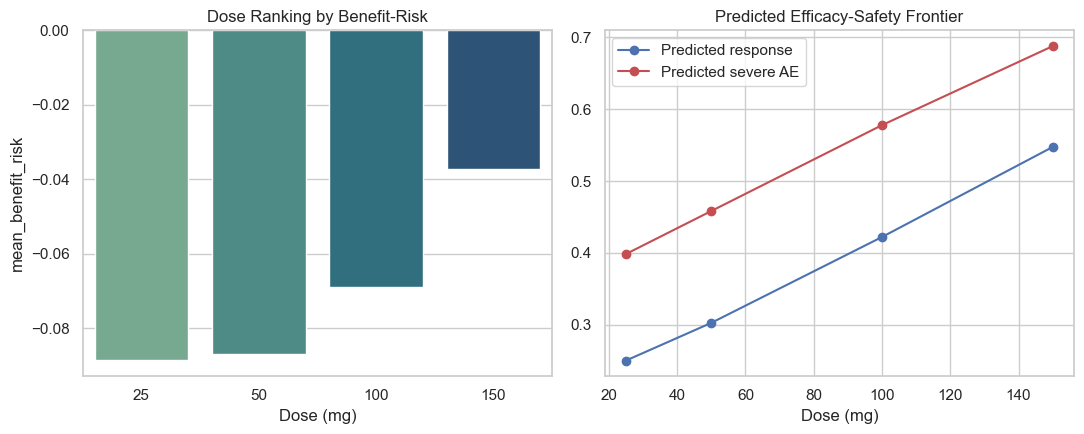

Top dose by mean benefit-risk score: 150 mg


In [12]:
best_dose = int(dose_policy.iloc[0]["dose_mg"])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=dose_policy.sort_values("dose_mg"), x="dose_mg", y="mean_benefit_risk", ax=ax[0], palette="crest")
ax[0].set_title("Dose Ranking by Benefit-Risk")
ax[0].set_xlabel("Dose (mg)")

tmp = dose_policy.sort_values("dose_mg")
ax[1].plot(tmp["dose_mg"], tmp["mean_response_prob"], marker="o", label="Predicted response", color="#4C72B0")
ax[1].plot(tmp["dose_mg"], tmp["mean_ae_prob"], marker="o", label="Predicted severe AE", color="#C44E52")
ax[1].set_title("Predicted Efficacy-Safety Frontier")
ax[1].set_xlabel("Dose (mg)")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Top dose by mean benefit-risk score: {best_dose} mg")

**What to read here.** The left bar ranks doses by mean benefit-risk utility — the winner at the top is the recommended dose under λ = 0.85. The right panel is the efficacy-safety *frontier* across doses: response rises with dose, AE rises with dose, and the optimal lands where the marginal increase in response per mg no longer justifies the marginal increase in AE. That crossover is dose-response pharmacology reduced to a single plot a clinical team can actually decide from.

## 7. Subgroup consistency checks

A recommendation that only works for the average patient is not a defensible label. Regulators will ask: does the dose choice hold up in women, in elderly patients, across regions? We recompute observed vs. predicted response/AE rates and mean utility within each subgroup with at least 120 patients. Flat patterns support a consistent label; large swings signal subgroup-specific dosing or eligibility criteria are needed.

In [13]:
def subgroup_perf(df: pd.DataFrame, group_col: str, min_n: int = 120):
    out = []
    for grp, sub in df.groupby(group_col):
        if len(sub) < min_n:
            continue
        out.append(
            {
                "group_col": group_col,
                "group": grp,
                "n": len(sub),
                "obs_response": sub["efficacy_response"].mean(),
                "pred_response": sub["p_response"].mean(),
                "obs_severe_ae": sub["grade3_ae"].mean(),
                "pred_severe_ae": sub["p_severe_ae"].mean(),
                "mean_benefit_risk": sub["benefit_risk_score"].mean(),
            }
        )
    return pd.DataFrame(out)

subgroup_table = pd.concat(
    [
        subgroup_perf(trial_scored, "sex"),
        subgroup_perf(trial_scored, "site_region"),
        subgroup_perf(trial_scored, "elderly"),
    ],
    ignore_index=True,
)

subgroup_table

,group_col,group,n,obs_response,pred_response,obs_severe_ae,pred_severe_ae,mean_benefit_risk
0,sex,F,2618,0.366310,0.364443,0.528266,0.534251,-0.089670
1,sex,M,2582,0.370256,0.373347,0.513943,0.506692,-0.057341
2,site_region,APAC,997,0.365095,0.368623,0.502508,0.494957,-0.052090
3,site_region,EU,1650,0.370909,0.365061,0.519394,0.516210,-0.073718
4,site_region,LATAM,453,0.381898,0.381558,0.540839,0.541978,-0.079123
5,site_region,NA,2100,0.364762,0.369229,0.527143,0.531530,-0.082571
6,elderly,0,3592,0.399777,0.397616,0.484688,0.484151,-0.013912
7,elderly,1,1608,0.297886,0.304638,0.602612,0.601914,-0.206989


C:\Users\diogo\AppData\Local\Temp\ipykernel_12808\1310197763.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_sub, x="group", y="mean_benefit_risk", palette="viridis")


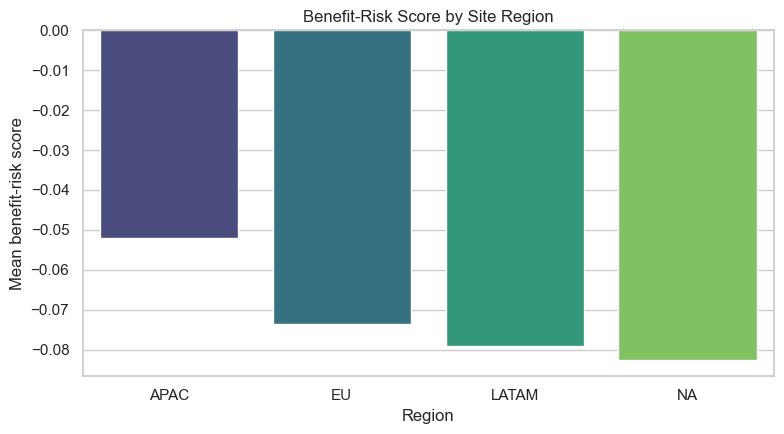

In [14]:
plot_sub = subgroup_table[subgroup_table["group_col"] == "site_region"].copy()
plt.figure(figsize=(8, 4.5))
sns.barplot(data=plot_sub, x="group", y="mean_benefit_risk", palette="viridis")
plt.title("Benefit-Risk Score by Site Region")
plt.xlabel("Region")
plt.ylabel("Mean benefit-risk score")
plt.tight_layout()
plt.show()

**What to read here.** Similar bar heights across regions support a single global label. A materially lower bar in one region would raise questions — is it subgroup biology, enrolment bias, site quality, or something the data-generating process encoded that the review should surface? This is where "consistency check" stops being a box-tick and becomes a decision input.

## 8. Decision sensitivity to safety penalty

A single-λ recommendation is brittle — different stakeholders carry different risk tolerances. We sweep λ across a clinically plausible range and record the best dose at each value. The output is a step function in λ: flat regions mean the recommendation is robust to preference uncertainty; step changes are the λ thresholds at which clinical opinion actually changes the dose.

In [15]:
penalties = np.linspace(0.40, 1.20, 17)
rows = []

for pen in penalties:
    tmp = trial_scored.copy()
    tmp["score"] = tmp["p_response"] - pen * tmp["p_severe_ae"]
    by_dose = tmp.groupby("dose_mg", as_index=False)["score"].mean()
    best_row = by_dose.sort_values("score", ascending=False).iloc[0]
    rows.append({"ae_penalty": pen, "best_dose": int(best_row["dose_mg"]), "best_score": best_row["score"]})

sens = pd.DataFrame(rows)
sens.head()

,ae_penalty,best_dose,best_score
0,0.40,150,0.272350
1,0.45,150,0.237962
2,0.50,150,0.203573
3,0.55,150,0.169185
4,0.60,150,0.134796


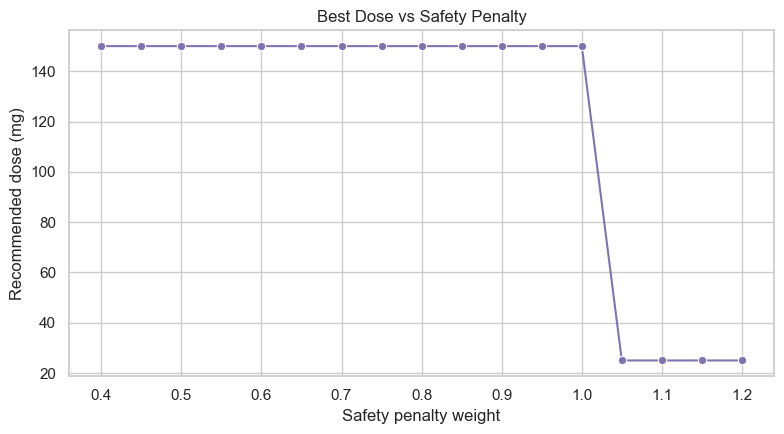

In [16]:
plt.figure(figsize=(8, 4.5))
sns.lineplot(data=sens, x="ae_penalty", y="best_dose", marker="o", color="#8172B2")
plt.title("Best Dose vs Safety Penalty")
plt.xlabel("Safety penalty weight")
plt.ylabel("Recommended dose (mg)")
plt.tight_layout()
plt.show()

**What to read here.** Flat horizontal regions mean the dose choice is stable within that range of safety preference — the recommendation is robust. Downward steps are the λ values at which a clinician who weighs safety more heavily would step down to a lower dose. This plot is the honest answer to "is our dose recommendation an artefact of how much we penalise AEs?" — and it is exactly the question a regulator or ethics committee will ask.

## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- Dose selection cannot be read off efficacy alone — the benefit-risk frontier and its sensitivity to λ are what a defensible recommendation rests on.
- Calibration matters more than discrimination for decision-grade probabilities: a high-AUC but miscalibrated model will mislead a clinician who reads the number as a probability.
- Subgroup consistency is a first-class check, not a sidebar. A recommendation that fails in women or the elderly is not a global recommendation.
- The sensitivity sweep in section 8 is the honest answer to "is this dose choice robust to preference?" — step functions are where clinical debate should focus.

**Limitations**

- The data-generating process is an explicit logistic model; real trial signals have non-linear and interaction effects the random forest is handling, but real evidence needs formal model diagnostics (residuals, PDPs, SHAP) and pre-specified analysis plans.
- The benefit-risk utility is linear in the two probabilities. Real utility functions may be non-linear (e.g. AE counts with diminishing marginal concern, or hard safety caps).
- Subgroups are univariate. Multi-way subgroup (elderly women in LATAM) would matter in a real programme and would demand larger samples or Bayesian borrowing across strata.
- Calibration is assessed by visual curve + Brier; a formal Hosmer-Lemeshow or calibration-slope test would be expected in a regulated submission.

**What a production version would add**

- **SHAP** and partial-dependence plots for covariate-effect defensibility.
- **Isotonic or Platt calibration** if the champion is miscalibrated in a narrow region.
- **Bootstrapped confidence intervals** on the dose ranking and λ-sensitivity curve.
- **Formal subgroup interaction tests** (treatment × subgroup) and multiplicity control.
- **Handoff to a CSR-ready table pack** — the outputs here map one-to-one to the tables a Clinical Study Report would include.